# AFOLU Calibration and Ramp Derivation (Multi-Scenario)

Calibrate a cohort-based carbon cycle model against the IAM's AFOLU CO₂ trajectory, then **invert it** to derive the land-use rate ramp that makes the extension consistent with the IAM's AFOLU pathway.

**Goal**: Solve for the ramp $r(t)$ that reproduces the IAM AFOLU curve post-2100 using a calibrated 4-predictor model.

**Model**: $\text{AFOLU}(t) \approx \beta + \gamma \cdot t + \alpha_{\text{trans}} \cdot F^{\text{trans}}(t) + \alpha_{\text{stock}} \cdot F^{\text{stock}}(t;\, \tau)$

In [1]:
# ============================================================================
# SCENARIO SELECTOR — Change this to process a different scenario
# ============================================================================
SCENARIO_KEY = "H"  # Options: "VL", "H", "HL", "L", "LN", "M", "ML"
# ============================================================================

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import importlib
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from src import config as cfg
from src.data import (
    load_csv, filter_scenario, get_variable,
    load_states, state_2100, rates_2100,
)
from src import carbon_model as cm
importlib.reload(cm)

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)

# Load scenario configuration
sc = cfg.get_scenario(SCENARIO_KEY)
print(f"Processing: {sc.model} | {sc.scenario}")
print(f"  Key: {sc.key}")
print(f"  State vars: {sc.state_vars}")
print(f"  Residual var: {sc.residual_var}")
print(f"  Output dir: {sc.output_dir}")
print(f"  Regrow vars: {cm.regrow_vars_for(sc.state_vars)}")

# Create output directory if needed
sc.output_dir.mkdir(parents=True, exist_ok=True)

Processing: GCAM 8s | SSP3 - High Emissions
  Key: H
  State vars: ['forest', 'c3ann', 'c3nfx', 'c3per', 'c4ann', 'c4per', 'pastr', 'range', 'urban']
  Residual var: forest
  Output dir: /div/no-backup-nac/users/bensan/extend-luh/output/H
  Regrow vars: ['forest']


## 1. Load IAM Target Trajectory

Extract the AFOLU CO2 emissions from the CSV. This is our target: the extension should produce fluxes whose *shape* matches this curve.

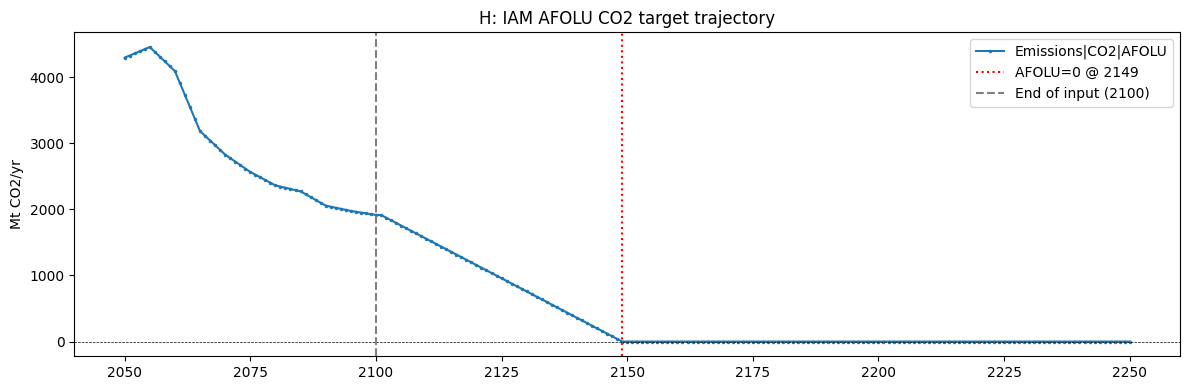

AFOLU at 2100: 1915.0 Mt CO2/yr
AFOLU at 2149: 0.0 Mt CO2/yr


In [3]:
df = load_csv()
sc_data = filter_scenario(df, scen=sc)
afolu_target = get_variable(sc_data, 'Emissions|CO2|AFOLU')

fig, ax = plt.subplots(figsize=(12, 4))
afolu_target.loc[2050:2250].plot(ax=ax, marker='.', ms=3)
ax.axhline(0, color='k', ls='--', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', label=f'AFOLU=0 @ {cfg.YR_AFOLU_ZERO}')
ax.axvline(cfg.YR_END_INPUT, color='gray', ls='--', label='End of input (2100)')
ax.set_ylabel('Mt CO2/yr'); ax.set_title(f'{sc.key}: IAM AFOLU CO2 target trajectory')
ax.legend(); plt.tight_layout(); plt.show()

print(f"AFOLU at 2100: {afolu_target.loc[2100]:.1f} Mt CO2/yr")
print(f"AFOLU at {cfg.YR_AFOLU_ZERO}: {afolu_target.loc[cfg.YR_AFOLU_ZERO]:.1f} Mt CO2/yr")

## 2. Load Gridded Input States

**Note**: This section requires gridded land-use state data. If unavailable for this scenario, calibration will proceed using simplified assumptions or placeholder values.

In [4]:
# Check if gridded data is available
try:
    ds_input = load_states(scen=sc)
    HAS_GRIDDED = True
    
    lat = ds_input.lat.values
    lon = ds_input.lon.values
    
    # Grid-cell area (km²) from latitude
    R_EARTH = 6371.0  # km
    dlat = np.abs(np.diff(lat[:2]))[0]
    dlon = np.abs(np.diff(lon[:2]))[0]
    lat_rad = np.deg2rad(lat)
    cell_area = (R_EARTH**2) * np.deg2rad(dlat) * np.deg2rad(dlon) * np.cos(lat_rad)
    cell_area_2d = np.broadcast_to(cell_area[:, np.newaxis], (len(lat), len(lon)))
    
    print(f"✓ Gridded data available")
    print(f"  Input years: {int(ds_input.time.values[0])}–{int(ds_input.time.values[-1])}")
    print(f"  Grid: {len(lat)} x {len(lon)}")
    print(f"  Cell area range: {cell_area.min():.1f} - {cell_area.max():.1f} km²")
    
except FileNotFoundError:
    HAS_GRIDDED = False
    print(f"⚠ No gridded data for {sc.key}")
    print(f"  Calibration will use global-average approximations")
    print(f"  (Gridded extension will not be possible)")

✓ Gridded data available
  Input years: 2024–2100
  Grid: 720 x 1440
  Cell area range: 1.7 - 772.8 km²


## 3. Carbon Model Parameters

Load carbon density and equilibrium parameters. These are scenario-dependent based on the state variables available.

In [ ]:
CARBON_DENSITY = cm.CARBON_DENSITY
C_EQ = cm.C_EQ
REGROW_VARS = cm.regrow_vars_for(sc.state_vars)
TC_TO_MTCO2 = cm.TC_TO_MTCO2

print(f"State variables for {sc.key}: {sc.state_vars}")
print(f"Regrowing types: {REGROW_VARS}")
print(f"Residual variable: {sc.residual_var}")
print(f"\nCarbon densities (tC/km²):")
for v in sc.state_vars:
    c_dens = CARBON_DENSITY.get(v, 0)
    c_eq = C_EQ.get(v, 0)
    regrow_str = " ← regrows" if v in REGROW_VARS else ""
    print(f"  {v:10s}  C={c_dens:6d}  C_eq={c_eq:6d}{regrow_str}")

State variables for H: ['forest', 'c3ann', 'c3nfx', 'c3per', 'c4ann', 'c4per', 'pastr', 'range', 'urban']
Regrowing types: ['forest']
Residual variable: forest

Carbon densities (tC/km²):
  forest      C= 10000  C_eq= 10000 ← regrows
  c3ann       C=   500  C_eq=     0
  c3nfx       C=   500  C_eq=     0
  c3per       C=   500  C_eq=     0
  c4ann       C=   500  C_eq=     0
  c4per       C=   500  C_eq=     0
  pastr       C=   800  C_eq=     0
  range       C=   600  C_eq=     0
  urban       C=   200  C_eq=     0


## 4. Compute Transition Flux (if gridded data available)

Transition flux = net carbon released/absorbed from land-use change, based on the difference in carbon density between source and destination land types.

In [6]:
if HAS_GRIDDED:
    # Compute transition flux for pre-2100 period
    input_years = ds_input.time.values.astype(int)
    input_flux_years = input_years[1:]  # transitions
    n_flux = len(input_flux_years)
    
    F_trans_pre = np.zeros(n_flux)
    area_incr_pre = {v: np.zeros(n_flux) for v in REGROW_VARS}
    
    for ti in range(1, len(input_years)):
        # Transition flux: sum of -ΔA_v × C_v × cell_area
        flux_t = 0.0
        for v in sc.state_vars:
            delta = ds_input[v].isel(time=ti).values - ds_input[v].isel(time=ti-1).values
            flux_t += np.nansum(-delta * CARBON_DENSITY[v] * cell_area_2d) * TC_TO_MTCO2
        F_trans_pre[ti-1] = flux_t
        
        # Area increments for regrowing types — NET change (not positive-only)
        for v in REGROW_VARS:
            delta = ds_input[v].isel(time=ti).values - ds_input[v].isel(time=ti-1).values
            area_incr_pre[v][ti-1] = np.nansum(delta * cell_area_2d)
    
    years_pre = input_flux_years  # transition years for forward solve
    
    # Calibrate on full pre-2100 period (stock flux needs full cohort history)
    afolu_cal = afolu_target.loc[input_flux_years].values
    
    print(f"✓ Computed transition flux for {input_flux_years[0]}-{input_flux_years[-1]}")
    print(f"  F_trans range: [{F_trans_pre.min():.1f}, {F_trans_pre.max():.1f}] Mt CO2/yr")
    print(f"  Calibration period: {input_flux_years[0]}-{input_flux_years[-1]} ({n_flux} years)")
    print(f"\nCumulative area change by 2100 (km²):")
    for v in REGROW_VARS:
        cum = area_incr_pre[v].sum()
        print(f"  {v}: {cum:+,.0f} km²")
else:
    # Placeholder: use simplified assumptions
    print("⚠ Using simplified calibration (no gridded data)")
    print("  This will produce a generic ramp based on AFOLU trajectory shape only")
    
    # Simplified: assume transition flux ~proportional to AFOLU
    CAL_START = 2050
    years_cal = np.arange(CAL_START, 2101)
    afolu_cal = afolu_target.loc[years_cal].values
    F_trans_pre = afolu_cal * 0.6  # rough estimate
    area_incr_pre = {v: np.ones(len(years_cal)) * 1000 for v in REGROW_VARS}
    input_flux_years = years_cal
    years_pre = years_cal

✓ Computed transition flux for 2025-2100
  F_trans range: [-1867.6, 1982.2] Mt CO2/yr
  Calibration period: 2025-2100 (76 years)

Cumulative area change by 2100 (km²):
  forest: -2,408,218 km²


## 5. Calibrate the 4-Predictor Model

Fit: AFOLU(t) = β + γ·t + α_trans·F_trans(t) + α_stock·F_stock(t, τ)

Profile likelihood optimization over τ ∈ [20, 200] years.


CALIBRATION RESULTS (H)
Optimal τ      = 20.0 years
R²             = 0.9238
RMSE           = 239.3 Mt CO2/yr
β (baseline)   = 2243.0 Mt CO2/yr
γ (trend)      = -355.0 Mt CO2/yr per decade
α_trans        = 0.369
α_stock        = 0.612

Model type: 4-predictor (full)



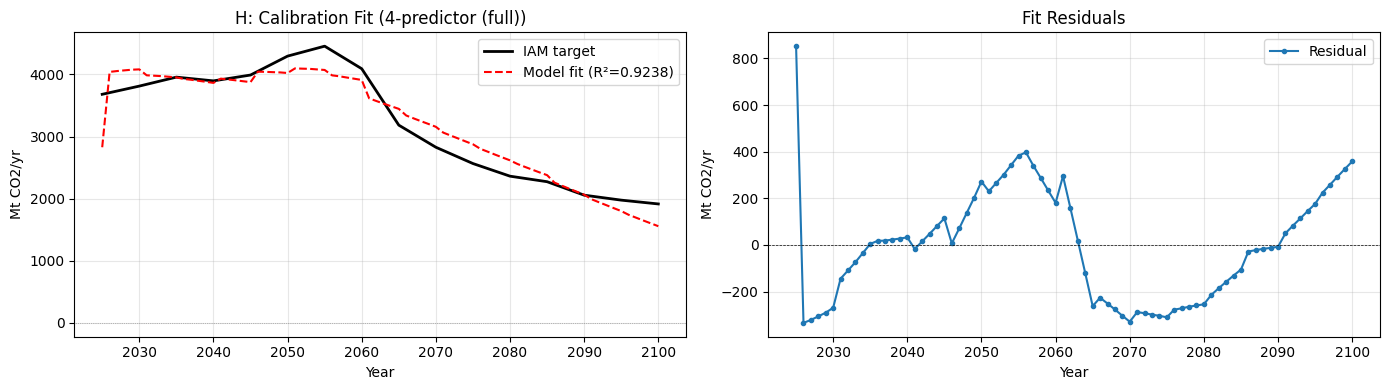

In [7]:
# Run calibration on full pre-2100 period (stock flux needs full cohort history)
cal_kwargs = dict(
    transition_flux=F_trans_pre,
    area_incr=area_incr_pre,
    afolu_target=afolu_cal,
    years=input_flux_years,
    tau_grid=np.arange(20, 201, 2),
    regrow_vars=REGROW_VARS,
)
if sc.tau_fixed is not None:
    cal_kwargs['tau_fixed'] = sc.tau_fixed
    print(f"Using tau_fixed = {sc.tau_fixed} (from scenario config)")

result = cm.calibrate_afolu_model(**cal_kwargs)

# Extract results
beta = result['beta']
gamma = result['gamma']
alpha_trans = result['alpha_trans']
alpha_stock = result['alpha_stock']
tau_opt = result['tau']
r2 = result['r2']
fitted = result['fitted']
residual = result['residual']

print(f"\n{'='*60}")
print(f"CALIBRATION RESULTS ({sc.key})")
print(f"{'='*60}")
if sc.tau_fixed is not None:
    print(f"τ (fixed)      = {tau_opt:.1f} years")
    if result['tau_opt'] is not None:
        print(f"τ profile opt  = {result['tau_opt']:.1f} years (for reference)")
else:
    print(f"Optimal τ      = {tau_opt:.1f} years")
print(f"R²             = {r2:.4f}")
print(f"RMSE           = {result['rmse']:.1f} Mt CO2/yr")
print(f"β (baseline)   = {beta:.1f} Mt CO2/yr")
print(f"γ (trend)      = {gamma:.1f} Mt CO2/yr per decade")
print(f"α_trans        = {alpha_trans:.3f}")
print(f"α_stock        = {alpha_stock:.3f}")

# ── Physical consistency check ──────────────────────────────
if alpha_stock < 0:
    print(f"\n⚠ alpha_stock < 0 ({alpha_stock:.3f}): unphysical sign")
    print(f"  → Refitting with 3-predictor model (dropping stock flux)...\n")
    
    n_cal = len(afolu_cal)
    time_trend_cal = (input_flux_years - input_flux_years.mean()) / 10.0
    X3 = np.column_stack([np.ones(n_cal), time_trend_cal, F_trans_pre])
    coefs3, _, _, _ = np.linalg.lstsq(X3, afolu_cal, rcond=None)
    beta, gamma, alpha_trans = coefs3
    alpha_stock = 0.0
    
    fitted = X3 @ coefs3
    residual = afolu_cal - fitted
    ss_res = np.sum(residual**2)
    ss_tot = np.sum((afolu_cal - afolu_cal.mean())**2)
    r2 = 1 - ss_res / ss_tot
    
    print(f"  3-predictor results:")
    print(f"  R²             = {r2:.4f}")
    print(f"  β (baseline)   = {beta:.1f} Mt CO2/yr")
    print(f"  γ (trend)      = {gamma:.1f} Mt CO2/yr per decade")
    print(f"  α_trans        = {alpha_trans:.3f}")
    print(f"  α_stock        = 0.000 (forced)")
    MODEL_TYPE = "3-predictor (no stock flux)"
else:
    MODEL_TYPE = "4-predictor (full)"
    
print(f"\nModel type: {MODEL_TYPE}")
print(f"{'='*60}\n")

# Plot fit
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(input_flux_years, afolu_cal, 'k-', lw=2, label='IAM target')
ax1.plot(input_flux_years, fitted, 'r--', lw=1.5, label=f'Model fit (R²={r2:.4f})')
ax1.axhline(0, color='gray', ls=':', lw=0.5)
ax1.set_xlabel('Year'); ax1.set_ylabel('Mt CO2/yr')
ax1.set_title(f'{sc.key}: Calibration Fit ({MODEL_TYPE})')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(input_flux_years, residual, 'o-', ms=3, label='Residual')
ax2.axhline(0, color='k', ls='--', lw=0.5)
ax2.set_xlabel('Year'); ax2.set_ylabel('Mt CO2/yr')
ax2.set_title('Fit Residuals')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 6. Forward Solve for AFOLU-Consistent Ramp

Invert the calibrated model to solve for r(t) that reproduces the IAM's post-2100 AFOLU trajectory.

In [8]:
if HAS_GRIDDED:
    # Compute unit-rate fluxes at 2100
    vals_2100 = state_2100(ds_input, scen=sc)
    rates_2100_dict = rates_2100(ds_input, scen=sc)
    
    # Normalise rates so they sum to zero per cell (matching extend_states).
    # Input data can have per-cell imbalances (especially with aggregated vars
    # like "forest"); without correction, the residual variable absorbs the
    # full imbalance in extend_states, causing a rate discontinuity at 2100.
    rate_sum = np.zeros_like(rates_2100_dict[sc.state_vars[0]], dtype=np.float64)
    for v in sc.state_vars:
        rate_sum += np.where(np.isfinite(rates_2100_dict[v]), rates_2100_dict[v], 0.0)
    land_mask_2100 = np.isfinite(vals_2100[sc.residual_var])
    rates_2100_dict[sc.residual_var] = np.where(
        land_mask_2100,
        rates_2100_dict[sc.residual_var] - rate_sum,
        rates_2100_dict[sc.residual_var])
    imbalance_area = np.nansum(rate_sum * cell_area_2d)
    print(f"Rate imbalance correction: {imbalance_area:.1f} km² redistributed to {sc.residual_var}")
    
    # Unit transition flux
    F_trans_unit = sum(
        np.nansum(-rates_2100_dict[v] * CARBON_DENSITY[v] * cell_area_2d) * TC_TO_MTCO2
        for v in sc.state_vars
    )
    
    # Unit area increments for regrowing types — NET change (matching calibration convention)
    dA_unit = {}
    for v in REGROW_VARS:
        dA_unit[v] = np.nansum(rates_2100_dict[v] * cell_area_2d)
    
    print(f"Unit-rate fluxes at 2100:")
    print(f"  F_trans_unit = {F_trans_unit:.1f} Mt CO₂/yr")
    print(f"  dA_unit = {dA_unit}")
    print()
    for v in REGROW_VARS:
        net = dA_unit[v]
        status = "NET GROWING" if net > 0 else "NET DECLINING"
        print(f"  {v:10s}: net Δarea = {net:+8.1f} km²/yr  → {status}")
else:
    # Placeholder estimates
    F_trans_unit = afolu_target.loc[2100] * 0.6
    dA_unit = {v: 1000.0 for v in REGROW_VARS}
    print(f"⚠ Using placeholder unit-rate flux: {F_trans_unit:.2f} Mt CO2/yr")

# Extension period
years_ext = np.arange(cfg.YR_END_INPUT + 1, cfg.YR_END_OUTPUT + 1)
afolu_target_ext = afolu_target.loc[years_ext].values

# Calibration residual at 2100 for boundary blending
cal_residual_2100 = fitted[-1] - afolu_cal[-1]
print(f"\nCalibration residual at 2100: {cal_residual_2100:+.1f} Mt CO₂/yr")

# Forward solve
ramp_result = cm.forward_solve_ramp(
    beta=beta, gamma=gamma,
    alpha_trans=alpha_trans, alpha_stock=alpha_stock, tau=tau_opt,
    area_incr_pre=area_incr_pre,
    F_trans_unit=F_trans_unit,
    dA_unit=dA_unit,
    afolu_target_ext=afolu_target_ext,
    years_pre=years_pre,
    years_ext=years_ext,
    regrow_vars=REGROW_VARS,
    calibration_residual_2100=cal_residual_2100,
)

ramp = ramp_result['ramp']
afolu_reconstructed = ramp_result['afolu_reconstructed']

print(f"\nRamp r(t) solved for {years_ext[0]}-{years_ext[-1]}")
print(f"  Model: {MODEL_TYPE}")
print(f"  Baseline (frozen at 2100): {ramp_result['baseline']:.1f} Mt CO2/yr")
if alpha_stock != 0:
    print(f"  alpha_trans * F_trans_unit = {alpha_trans * F_trans_unit:.1f}")
    print(f"  alpha_stock active: yes (tau={tau_opt:.0f})")
else:
    denom_val = ramp_result['baseline'] + alpha_trans * F_trans_unit
    print(f"  Denom = baseline + alpha_trans * F_trans_unit = {denom_val:.1f}")
    print(f"  → r(t) = AFOLU_target(t) / {denom_val:.1f}")
print(f"  r(2101) = {ramp[0]:.4f}")
print(f"  r reaches 0 by year {years_ext[np.where(ramp < 1e-6)[0][0]] if np.any(ramp < 1e-6) else 'never'}")
print(f"  RMSE vs target: {np.sqrt(np.mean(ramp_result['residual']**2)):.2f} Mt CO2/yr")

# Summary at key years
print(f"\n{'Year':>6s}  {'r(t)':>8s}  {'IAM':>10s}  {'Recon':>10s}  {'Resid':>8s}")
print("-" * 50)
for yr in [2101, 2110, 2125, 2140, 2149, 2150, 2200, 2300]:
    idx = yr - years_ext[0]
    if 0 <= idx < len(years_ext):
        print(f"  {yr:>4d}  {ramp[idx]:8.4f}  {afolu_target_ext[idx]:10.1f}  "
              f"{afolu_reconstructed[idx]:10.1f}  {ramp_result['residual'][idx]:8.1f}")

# Committed removals check (what happens if r=0 from 2101)
if alpha_stock != 0:
    G_end_pre = ramp_result['G_end_pre']
    decay = np.exp(-1.0 / tau_opt)
    G_test = {v: G_end_pre[v] for v in REGROW_VARS}
    committed = np.zeros(min(100, len(years_ext)))
    for t in range(len(committed)):
        for v in REGROW_VARS:
            G_test[v] *= decay
        S = sum(-(C_EQ[v] / tau_opt) * G_test[v] * TC_TO_MTCO2
                for v in REGROW_VARS if C_EQ[v] > 0)
        committed[t] = alpha_stock * S

    print(f"\nCommitted stock-change (r=0 scenario):")
    print(f"  2101: {committed[0]:+.0f} Mt CO₂/yr")
    if len(committed) > 48:
        print(f"  2149: {committed[48]:+.0f} Mt CO₂/yr")
    print(f"  Half-life: {tau_opt * np.log(2):.0f} yr")

Rate imbalance correction: 21914.2 km² redistributed to forest
Unit-rate fluxes at 2100:
  F_trans_unit = 1223.2 Mt CO₂/yr
  dA_unit = {'forest': np.float64(-35112.23261741065)}

  forest    : net Δarea = -35112.2 km²/yr  → NET DECLINING

Calibration residual at 2100: -358.1 Mt CO₂/yr

Ramp r(t) solved for 2101-2500
  Model: 4-predictor (full)
  Baseline (frozen at 2100): 911.9 Mt CO2/yr
  alpha_trans * F_trans_unit = 452.0
  alpha_stock active: yes (tau=20)
  r(2101) = 0.8016
  r reaches 0 by year 2143
  RMSE vs target: 49.61 Mt CO2/yr

  Year      r(t)         IAM       Recon     Resid
--------------------------------------------------
  2101    0.8016      1915.0      1591.0    -324.0
  2110    0.6566      1555.9      1424.2    -131.7
  2125    0.3489       957.5       928.1     -29.4
  2140    0.0490       359.1       352.5      -6.6
  2149    0.0000         0.0       183.3     183.3
  2150    0.0000         0.0       174.3     174.3
  2200    0.0000         0.0        14.3      14

In [ ]:
beta

np.float64(2243.039922962294)

## 7. Plot Ramp and Reconstructed AFOLU

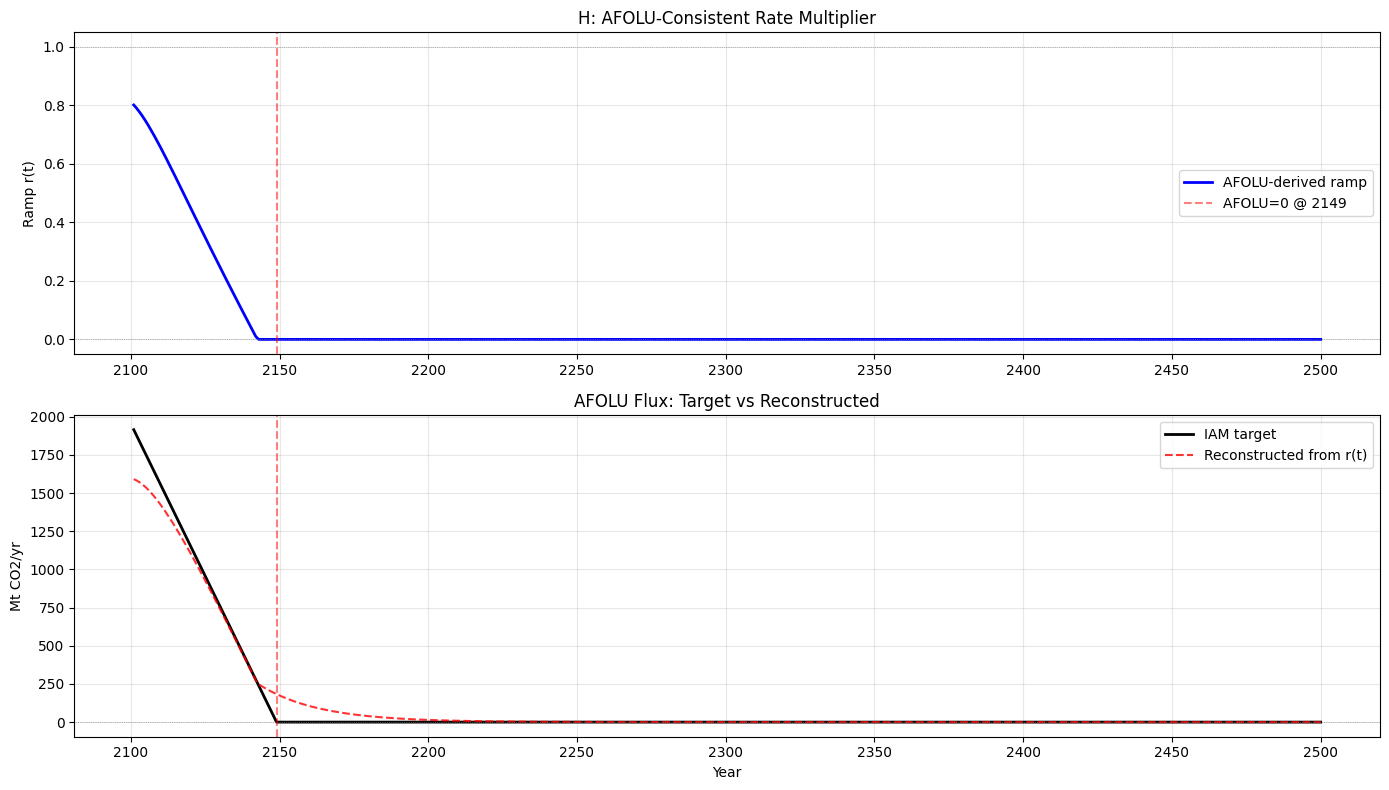

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Ramp
ax1.plot(years_ext, ramp, 'b-', lw=2, label='AFOLU-derived ramp')
ax1.axhline(0, color='gray', ls=':', lw=0.5)
ax1.axhline(1, color='gray', ls=':', lw=0.5)
ax1.axvline(cfg.YR_AFOLU_ZERO, color='r', ls='--', alpha=0.5, label=f'AFOLU=0 @ {cfg.YR_AFOLU_ZERO}')
ax1.set_ylabel('Ramp r(t)'); ax1.set_title(f'{sc.key}: AFOLU-Consistent Rate Multiplier')
ax1.legend(); ax1.grid(alpha=0.3)

# Reconstructed vs target
ax2.plot(years_ext, afolu_target_ext, 'k-', lw=2, label='IAM target')
ax2.plot(years_ext, afolu_reconstructed, 'r--', lw=1.5, alpha=0.8, label='Reconstructed from r(t)')
ax2.axhline(0, color='gray', ls=':', lw=0.5)
ax2.axvline(cfg.YR_AFOLU_ZERO, color='r', ls='--', alpha=0.5)
ax2.set_xlabel('Year'); ax2.set_ylabel('Mt CO2/yr')
ax2.set_title('AFOLU Flux: Target vs Reconstructed')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 8. Save Calibration Results

In [11]:
output_file = sc.output_dir / 'afolu_calibration.npz'

np.savez(
    output_file,
    years=years_ext,
    ramp=ramp,
    tau=tau_opt,
    beta=beta,
    gamma=gamma,
    alpha_trans=alpha_trans,
    alpha_stock=alpha_stock,
    r2=r2,
    afolu_target=afolu_target_ext,
    afolu_reconstructed=afolu_reconstructed,
    residual=ramp_result['residual'],
)

print(f"✓ Saved calibration to: {output_file}")
print(f"  Contains: years, ramp, tau, beta, gamma, alpha_trans, alpha_stock, r2, afolu_target, afolu_reconstructed, residual")
print(f"\n{'='*60}")
print(f"CALIBRATION COMPLETE for {sc.key}")
print(f"{'='*60}")
if HAS_GRIDDED:
    print(f"✓ Ready for gridded extension (notebook 03)")
else:
    print(f"⚠ Gridded extension not possible (no states file)")
    print(f"  Ramp can still be used for analysis/comparison")

✓ Saved calibration to: /div/no-backup-nac/users/bensan/extend-luh/output/H/afolu_calibration.npz
  Contains: years, ramp, tau, beta, gamma, alpha_trans, alpha_stock, r2, afolu_target, afolu_reconstructed, residual

CALIBRATION COMPLETE for H
✓ Ready for gridded extension (notebook 03)
